# DATA 101 – Module 6 - Session 2
## Exploratory Data Analysis (EDA) Demo

Topics:
- Descriptive statistics
- Distributions
- Outliers
- Correlation
- Scatterplots


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)

from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
df = iris.frame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Basic Data Overview

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [ ]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## Measures of Central Tendency

In [ ]:
df.mean(numeric_only=True)

,0
sepal length (cm),5.843333
sepal width (cm),3.057333
petal length (cm),3.758000
petal width (cm),1.199333
target,1.000000


In [ ]:
df.median(numeric_only=True)

,0
sepal length (cm),5.80
sepal width (cm),3.00
petal length (cm),4.35
petal width (cm),1.30
target,1.00


In [ ]:
df.mode().iloc[0]

,0
sepal length (cm),5.0
sepal width (cm),3.0
petal length (cm),1.4
petal width (cm),0.2
target,0.0


## Variability & Spread

In [ ]:
df.var(numeric_only=True)

,0
sepal length (cm),0.685694
sepal width (cm),0.189979
petal length (cm),3.116278
petal width (cm),0.581006
target,0.671141


In [ ]:
df.std(numeric_only=True)

,0
sepal length (cm),0.828066
sepal width (cm),0.435866
petal length (cm),1.765298
petal width (cm),0.762238
target,0.819232


In [ ]:
df.quantile([0.25, 0.5, 0.75])

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0.25,5.1,2.8,1.60,0.3,0.0
0.50,5.8,3.0,4.35,1.3,1.0
0.75,6.4,3.3,5.10,1.8,2.0


## Distribution Visualization

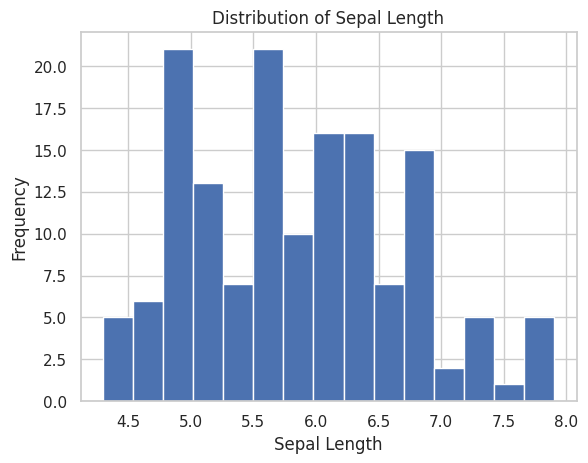

In [ ]:
plt.figure()
plt.hist(df['sepal length (cm)'], bins=15)
plt.xlabel('Sepal Length')
plt.ylabel('Frequency')
plt.title('Distribution of Sepal Length')
plt.show()

## Outlier Detection (IQR Method)

In [ ]:
Q1 = df['sepal length (cm)'].quantile(0.25)
Q3 = df['sepal length (cm)'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['sepal length (cm)'] < lower) |
              (df['sepal length (cm)'] > upper)]
outliers

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target


In [ ]:
# add species
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

# Within-Species Outlier Detection
for species, subset in df.groupby('species'):
    Q1 = subset['sepal length (cm)'].quantile(0.25)
    Q3 = subset['sepal length (cm)'].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = subset[
        (subset['sepal length (cm)'] < lower) |
        (subset['sepal length (cm)'] > upper)
    ]

    print(f"{species}: {len(outliers)} outliers")

setosa: 0 outliers
versicolor: 0 outliers
virginica: 1 outliers


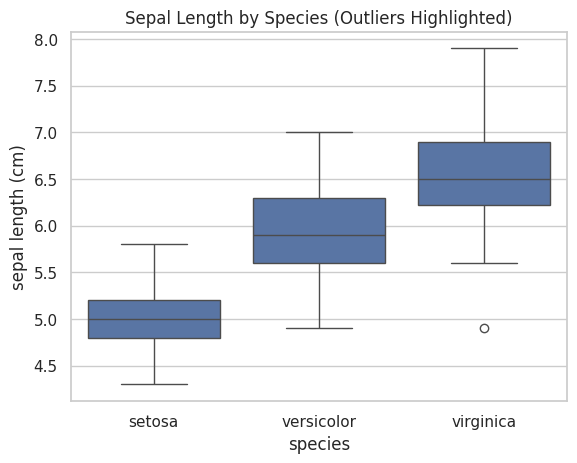

In [ ]:
plt.figure()
sns.boxplot(
    data=df,
    x='species',
    y='sepal length (cm)',
    flierprops=dict(marker='o', markersize=6)
)

plt.title("Sepal Length by Species (Outliers Highlighted)")
plt.show()

## Outlier Detection (Z-score Method)

In [ ]:
from scipy.stats import zscore

# Compute z-scores
df['z_sepal_length'] = zscore(df['sepal length (cm)'])

# Identify outliers (|z| > 3)
z_outliers = df[np.abs(df['z_sepal_length']) > 3]

z_outliers

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species,z_sepal_length


## Correlation Matrix

In [ ]:
corr = df.drop(columns=['target']).corr(numeric_only=True)
corr

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),z_sepal_length
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,1.000000
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.117570
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.871754
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.817941
z_sepal_length,1.000000,-0.117570,0.871754,0.817941,1.000000


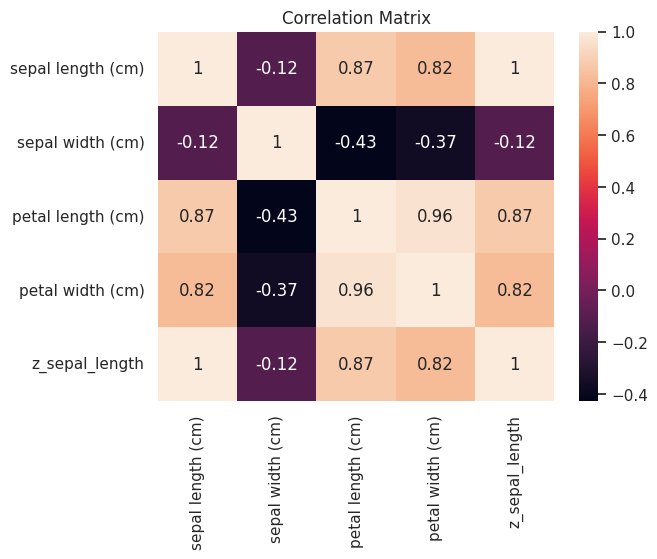

In [ ]:
plt.figure()
sns.heatmap(corr, annot=True)
plt.title('Correlation Matrix')
plt.show()

## Scatterplot

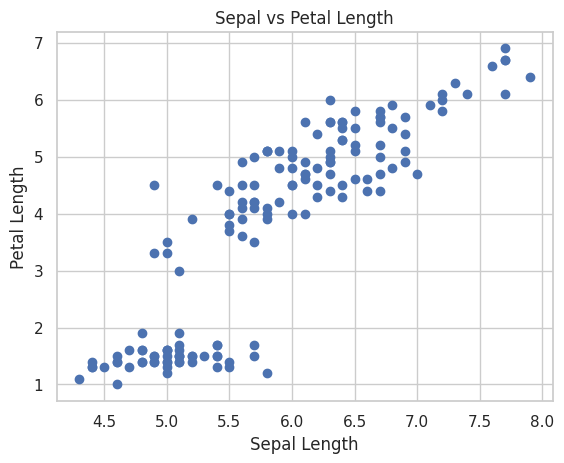

In [ ]:
plt.figure()
plt.scatter(df['sepal length (cm)'], df['petal length (cm)'])
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.title('Sepal vs Petal Length')
plt.show()

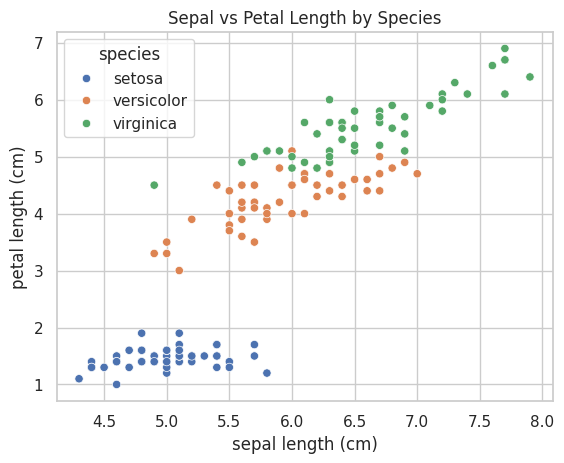

In [ ]:
# Add species names
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))

plt.figure()
sns.scatterplot(
    data=df,
    x='sepal length (cm)',
    y='petal length (cm)',
    hue='species'
)

plt.title("Sepal vs Petal Length by Species")
plt.show()

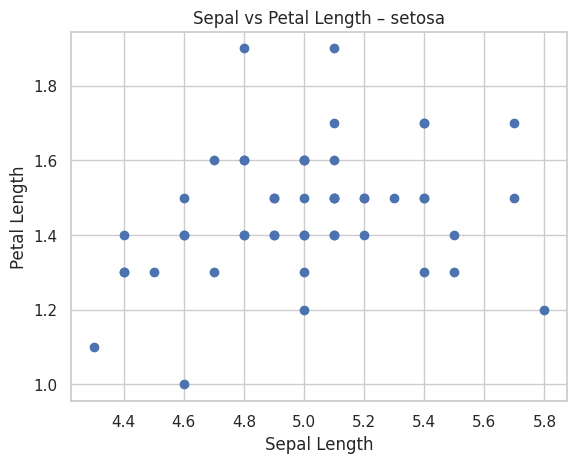

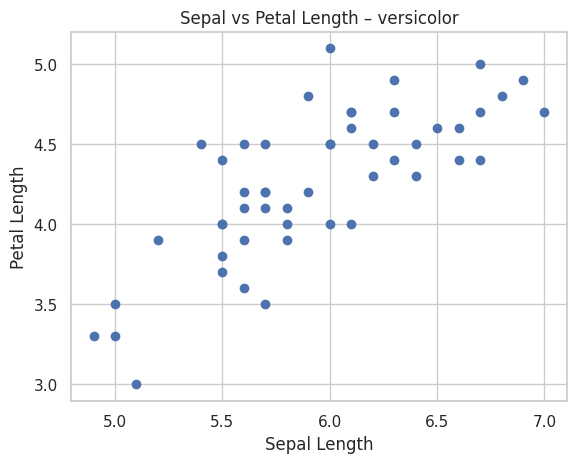

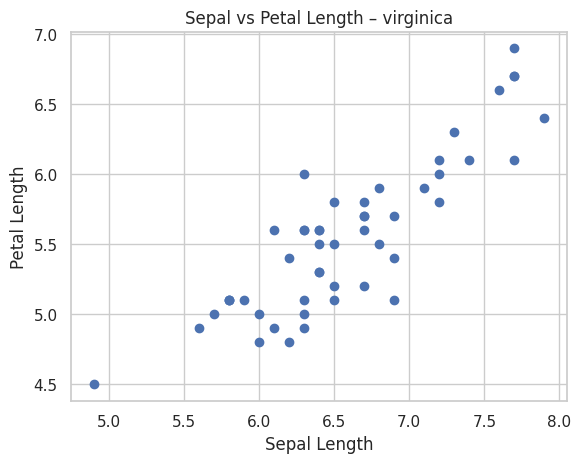

In [ ]:
for species in df['species'].unique():
    subset = df[df['species'] == species]

    plt.figure()
    plt.scatter(
        subset['sepal length (cm)'],
        subset['petal length (cm)']
    )

    plt.title(f"Sepal vs Petal Length – {species}")
    plt.xlabel("Sepal Length")
    plt.ylabel("Petal Length")
    plt.show()

## Correlation matrices per species

In [ ]:
# Correlation matrices per species
species_corr = df.drop(columns=['target']).groupby('species').corr(numeric_only=True)

species_corr

sepal length (cm)  sepal width (cm)  \
species                                                             
setosa     sepal length (cm)           1.000000          0.742547   
           sepal width (cm)            0.742547          1.000000   
           petal length (cm)           0.267176          0.177700   
           petal width (cm)            0.278098          0.232752   
           z_sepal_length              1.000000          0.742547   
versicolor sepal length (cm)           1.000000          0.525911   
           sepal width (cm)            0.525911          1.000000   
           petal length (cm)           0.754049          0.560522   
           petal width (cm)            0.546461          0.663999   
           z_sepal_length              1.000000          0.525911   
virginica  sepal length (cm)           1.000000          0.457228   
           sepal width (cm)            0.457228          1.000000   
           petal length (cm)           0.864225          0.401045   
           petal width (cm)            0.281108          0.537728   
           z_sepal_length              1.000000          0.457228   

                              petal length (cm)  petal width (cm)  \
species                                                             
setosa     sepal length (cm)           0.267176          0.278098   
           sepal width (cm)            0.177700          0.232752   
           petal length (cm)           1.000000          0.331630   
           petal width (cm)            0.331630          1.000000   
           z_sepal_length              0.267176          0.278098   
versicolor sepal length (cm)           0.754049          0.546461   
           sepal width (cm)            0.560522          0.663999   
           petal length (cm)           1.000000          0.786668   
           petal width (cm)            0.786668          1.000000   
           z_sepal_length              0.754049          0.546461   
virginica  sepal length (cm)           0.864225          0.281108   
           sepal width (cm)            0.401045          0.537728   
           petal length (cm)           1.000000          0.322108   
           petal width (cm)            0.322108          1.000000   
           z_sepal_length              0.864225          0.281108   

                              z_sepal_length  
species                                       
setosa     sepal length (cm)        1.000000  
           sepal width (cm)         0.742547  
           petal length (cm)        0.267176  
           petal width (cm)         0.278098  
           z_sepal_length           1.000000  
versicolor sepal length (cm)        1.000000  
           sepal width (cm)         0.525911  
           petal length (cm)        0.754049  
           petal width (cm)         0.546461  
           z_sepal_length           1.000000  
virginica  sepal length (cm)        1.000000  
           sepal width (cm)         0.457228  
           petal length (cm)        0.864225  
           petal width (cm)         0.281108  
           z_sepal_length           1.000000